In [1]:
import torch
import numpy as np 
import os 
from PIL import Image
import pandas as pd 
import json
import ast
import cv2
import h5py


import torch 
from torch.utils.data import Dataset
from torchvision import transforms
import collections


In [2]:

def resize_keypoints(keypoints, original_size, new_size):
    """
    Resize keypoints to match the new image size.

    Args:
        keypoints (list of tuple): List of keypoint coordinates [(x, y), ...]. for One person
        original_size (tuple): Original image size (H, W).
        new_size (tuple): Target image size (H, W).

    Returns:     
        list of tuple: Resized keypoint coordinates [(x', y'), ...]. for one person
    """
    orig_h, orig_w = original_size
    new_h, new_w = new_size
    scale_h, scale_w = new_h / orig_h, new_w / orig_w

    resized_keypoints = [(x * scale_w, y * scale_h) for x, y in keypoints]
    return resized_keypoints


def clamp_to_range(landmarks, new_size):
    """
    Clamps (x, y) coordinates to [0, width-1] x [0, height-1].
    If a landmark is out of range, set it to (-1, -1).
    
    Args:
      landmarks (list of tuples): [(x0, y0), (x1, y1), ...]
      width (int):  target image width (e.g., 224)
      height (int): target image height (e.g., 224)
      
    Returns:
      list of tuples: updated landmarks
    """
    width, height = new_size
    clamped = []
    for (x, y) in landmarks:
        # Check if (x, y) is out of [0, width-1] or [0, height-1]
        if x <= 0 or x >= width or y <= 0 or y >= height:
            # Mark invalid by (-1, -1)
            clamped.append((-1, -1))
        else:
            # Keep original coordinate (or you can round if you want integer)
            clamped.append((x, y))
    return clamped


limbs_pairs_person  = [
    (0, 5),   # Nose → Left Shoulder
    (0, 6),   # Nose → Right Shoulder
    (0, 1),   # Nose → Left Eye
    (0, 2),   # Nose → Right Eye
    (1, 3),   # Left Eye → Left Ear
    (2, 4),   # Right Eye → Right Ear
    (5, 6),   # Left Shoulder → Right Shoulder
    (5, 7),   # Left Shoulder → Left Elbow
    (7, 9),   # Left Elbow → Left Wrist
    (6, 8),   # Right Shoulder → Right Elbow
    (8, 10),  # Right Elbow → Right Wrist
    (5, 11),  # Left Shoulder → Left Hip
    (6, 12),  # Right Shoulder → Right Hip
    (11, 12), # Left Hip → Right Hip
    (11, 13), # Left Hip → Left Knee
    (13, 15), # Left Knee → Left Ankle
    (12, 14), # Right Hip → Right Knee
    (14, 16)  # Right Knee → Right Ankle
    ]



# 1) Define the facial edges for 68 landmarks
jaw = [(i, i+1) for i in range(0, 16)]
left_eyebrow_1 = [(i, i+1) for i in range(17, 21)]
right_eyebrow_1 = [(i, i+1) for i in range(22, 26)]
nose_bridge = [(i, i+1) for i in range(27, 30)]
nose_base = [(i, i+1) for i in range(31, 35)]
left_eye = [(36, 37), (37, 38), (38, 39), (39, 40), (40, 41), (41, 36)]
right_eye = [(42, 43), (43, 44), (44, 45), (45, 46), (46, 47), (47, 42)]
mouth_outer = [
    (48, 49), (49, 50), (50, 51), (51, 52), (52, 53), (53, 54),
    (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 48)
]
mouth_inner = [
    (60, 61), (61, 62), (62, 63), (63, 64), (64, 65),
    (65, 66), (66, 67), (67, 60)
]


chin = [(7,8),(8,9)]
chin_to_mouth = [(8,65),(8,66),(7, 48),(9, 54)]
nose_to_mouth = [(30,48),(30,54),(30,55),(30,56),(30,57),(30,58),(30,59)]
mouth_entry = [(48, 54), (49, 55), (50, 56), (51, 57), (52, 58), (53, 59)]
eye_left_entry = [(36, 41),(37, 40),(38, 39)]
eye_right_entry = [(42, 47), (43, 46),(44, 45)]
left_eyebrow = [(17, 19), (19, 21)]
right_eyebrow = [(22, 24), (24, 26)]
mouth_open = [(51,56),(50,57)]

limbs_pairs_face_1 = (jaw + left_eyebrow_1 + right_eyebrow_1 +
              nose_bridge + nose_base +
              left_eye + right_eye +
              mouth_outer + mouth_inner)


cunstom_limbs = (eye_left_entry
                 + eye_right_entry
                 +left_eyebrow
                 +right_eyebrow
                 +mouth_inner
                 +mouth_open
                ) # 20 limbs

limbs_pairs_face =  (cunstom_limbs + 
                     limbs_pairs_face_1)



def generate_person_limbs_heatmap(keypoints_list, new_size, heatmap_size, limb_pairs, sigma=2):
    """
    Generate heatmaps for limbs (connections between keypoints) across multiple persons.

    Args:
        keypoints_list (list of list): List of keypoints for all persons, where each person's keypoints
            are a list of (x, y).
        original_size (tuple): Original image size (H, W).
        new_size (tuple): Resized image dimensions (H, W) used before mapping to the heatmap.
        heatmap_size (tuple): The desired heatmap size (H, W).
        limb_pairs (list of tuples): List of limb pairs, each a tuple (start_index, end_index).
        sigma (float): Standard deviation for the Gaussian.

    Returns:
        torch.Tensor: Limb heatmaps of shape (num_limbs, H, W).
    """
    num_limbs = len(limb_pairs)
    H, W = heatmap_size
    img_H, img_W = new_size  # Resized image dimensions

    # Create an empty tensor for all limb heatmaps
    heatmaps = torch.zeros((num_limbs, H, W), dtype=torch.float32)

    # Create a meshgrid for the heatmap coordinates
    x = torch.arange(W, dtype=torch.float32)
    y = torch.arange(H, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing='ij')  # Shapes: (H, W)

    # Process each limb
    for l, (idx1, idx2) in enumerate(limb_pairs):
        # Iterate over each person's keypoints
        for person_kp in keypoints_list:
            # Check that both keypoints exist for this person
            if max(idx1, idx2) >= len(person_kp):
                continue

            # Get the keypoints for the limb
            y1, x1 = person_kp[idx1]
            y2, x2 = person_kp[idx2]

            # Scale keypoint coordinates to fit the heatmap size
            x1 = x1 * (W / img_W)
            y1 = y1 * (H / img_H)
            x2 = x2 * (W / img_W)
            y2 = y2 * (H / img_H)

            # Optionally, skip limbs with invalid coordinates (outside heatmap boundaries)
            if (x1 < 0 or y1 < 0 or x1 >= W or y1 >= H or
                x2 < 0 or y2 < 0 or x2 >= W or y2 >= H):
                continue

            # Compute differences and squared length of the limb vector
            dx = x2 - x1
            dy = y2 - y1
            norm_sq = dx**2 + dy**2

            if norm_sq < 1e-6:
                # If the limb is degenerate, create a heatmap like a keypoint
                limb_heatmap = torch.exp(-((xx - x1)**2 + (yy - y1)**2) / (2 * sigma**2))
            else:
                # Compute the projection factor t for each pixel on the line direction.
                t = ((xx - x1) * dx + (yy - y1) * dy) / norm_sq
                # Clamp t to lie between 0 and 1 (i.e. restrict to the segment)
                t = t.clamp(0, 1)
                # Compute the projection coordinates (closest points on the segment)
                xp = x1 + t * dx
                yp = y1 + t * dy
                # Compute squared distances from each pixel to the limb
                d2 = (xx - xp)**2 + (yy - yp)**2
                # Apply the Gaussian
                limb_heatmap = torch.exp(-d2 / (2 * sigma**2))

            # Accumulate the heatmap (if multiple persons contribute to the same limb)
            heatmaps[l] += limb_heatmap

        # Clamp the accumulated heatmap values to avoid saturation beyond 1
        heatmaps[l] = heatmaps[l].clamp(max=1.0)
    
    return heatmaps



def generate_face_limbs_heatmap(keypoints_list, new_size, heatmap_size, limb_pairs, sigma=2):
    """
    Generate heatmaps for limbs (connections between keypoints) across multiple persons.

    Args:
        keypoints_list (list of list): List of keypoints for all persons, where each person's keypoints
            are a list of (x, y).
        original_size (tuple): Original image size (H, W).
        new_size (tuple): Resized image dimensions (H, W) used before mapping to the heatmap.
        heatmap_size (tuple): The desired heatmap size (H, W).
        limb_pairs (list of tuples): List of limb pairs, each a tuple (start_index, end_index).
        sigma (float): Standard deviation for the Gaussian.

    Returns:
        torch.Tensor: Limb heatmaps of shape (num_limbs, H, W).
    """
    num_limbs = len(limb_pairs)
    H, W = heatmap_size
    img_H, img_W = new_size  # Resized image dimensions

    # Create an empty tensor for all limb heatmaps
    heatmaps = torch.zeros((num_limbs, H, W), dtype=torch.float32)

    # Create a meshgrid for the heatmap coordinates
    x = torch.arange(W, dtype=torch.float32)
    y = torch.arange(H, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing='ij')  # Shapes: (H, W)

    # Process each limb
    for l, (idx1, idx2) in enumerate(limb_pairs):
        # Iterate over each person's keypoints
        for person_kp in keypoints_list:
            # Check that both keypoints exist for this person
            if max(idx1, idx2) >= len(person_kp):
                continue

            # Get the keypoints for the limb
            x1, y1 = person_kp[idx1]
            x2, y2 = person_kp[idx2]

            # Scale keypoint coordinates to fit the heatmap size
            x1 = x1 * (W / img_W)
            y1 = y1 * (H / img_H)
            x2 = x2 * (W / img_W)
            y2 = y2 * (H / img_H)

            # Optionally, skip limbs with invalid coordinates (outside heatmap boundaries)
            if (x1 < 0 or y1 < 0 or x1 >= W or y1 >= H or
                x2 < 0 or y2 < 0 or x2 >= W or y2 >= H):
                continue

            # Compute differences and squared length of the limb vector
            dx = x2 - x1
            dy = y2 - y1
            norm_sq = dx**2 + dy**2

            if norm_sq < 1e-6:
                # If the limb is degenerate, create a heatmap like a keypoint
                limb_heatmap = torch.exp(-((xx - x1)**2 + (yy - y1)**2) / (2 * sigma**2))
            else:
                # Compute the projection factor t for each pixel on the line direction.
                t = ((xx - x1) * dx + (yy - y1) * dy) / norm_sq
                # Clamp t to lie between 0 and 1 (i.e. restrict to the segment)
                t = t.clamp(0, 1)
                # Compute the projection coordinates (closest points on the segment)
                xp = x1 + t * dx
                yp = y1 + t * dy
                # Compute squared distances from each pixel to the limb
                d2 = (xx - xp)**2 + (yy - yp)**2
                # Apply the Gaussian
                limb_heatmap = torch.exp(-d2 / (2 * sigma**2))

            # Accumulate the heatmap (if multiple persons contribute to the same limb)
            heatmaps[l] += limb_heatmap

        # Clamp the accumulated heatmap values to avoid saturation beyond 1
        heatmaps[l] = heatmaps[l].clamp(max=1.0)
    
    return heatmaps



In [3]:
    
    # VGAF transforms
general_transforms = {
        'train': transforms.Compose([
            #transforms.RandomResizedCrop(size=(224, 224)),
            #transforms.RandomHorizontalFlip(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]),
        'val': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

In [4]:

def Savelimbss(data_folder_src,csv_file_src, data_folder_dst, csv_file_dst,  heatmap_size = (56,56), sigma=1, score=0.1):
    # create dir save data
    os.makedirs(data_folder_dst, exist_ok=True)
    
    with open(os.path.join(csv_file_src), 'r') as file:
        annotations = json.load(file)

    keep_files_names =[]

    for index in range(len(annotations)):
        annotation =   annotations[index]
        label_emotion = annotation['label_emotion']
        file_name = annotation['file_name']
        persons = annotation["persons"]#[0]
        faces = annotation["faces"]
        ##faces= annotation.get("faces", [])

         # Load and process the image
        image_context = Image.open(os.path.join( data_folder_src, annotation['file_name']))
        if image_context.mode != 'RGB':
            image_context = image_context.convert('RGB')
        original_size = image_context.size
        new_size = (224, 224)
      
        image_context = image_context.resize(new_size, Image.LANCZOS)
        
        if not persons['pose']:
            keypoints_list = [] # format (y,  x)
        else:
            keypoints_list = [[ kp[:2] if kp[-1] >= score else (-1, -1) for kp in keypoints ]  for keypoints in persons['pose'][0] ]
 
        
        if len(keypoints_list)!=0 and len(faces) != 0:
            # Iterate through each person's keypoints
            keypoints_list_resized = [resize_keypoints(person_kp, original_size, new_size) for person_kp in keypoints_list]
            landmarks_list_resized = [resize_keypoints(face_kp, original_size, new_size) for face_kp in faces]
            landmarks_list_resized = [clamp_to_range(face_kp, new_size) for face_kp in landmarks_list_resized]

            limbs_person_gt = generate_person_limbs_heatmap(keypoints_list_resized, new_size, heatmap_size, limbs_pairs_person, sigma)
            limbs_face_gt = generate_face_limbs_heatmap(landmarks_list_resized, new_size, heatmap_size, limbs_pairs_face, sigma)

       
        # output_person_limb = data_folder_dst+'/'+str(file_name)+'_person_limb.pt'
        # torch.save(limbs_person_gt, output_person_limb)
        # output_face_limb = data_folder_dst+'/'+str(file_name)+'_face_limb.pt'
        # torch.save(limbs_face_gt, output_face_limb)
        
        # print("saved:", output_face_limb)

        # data_info = {
        #     "file_name":file_name,
        #     "label_emotion": label_emotion,
        #     "persons": persons,
        #     "faces":faces,
        #     }
        # keep_files_names.append(data_info)
        break
        # if index==5:
        #     break

    with open(csv_file_dst, 'w') as file:
        json.dump(keep_files_names, file, indent=4)
    return limbs_person_gt, limbs_face_gt,  image_context



In [ ]:
csv_file_src =  "...../GAF_3.0/train_annotation_all_vitpose_kp_fa.json"
data_folder_src= '...../GAF_3.0/Train_224x224'

csv_file_dst =  "...../GAF_3.0/train_annotation_all_vitpose_limbs.json"
data_folder_dst= '....../GAF_3.0/Train_heatmap_56_2' # 83 limbs special case

p, f, img =Savelimbss(data_folder_src,csv_file_src, data_folder_dst, csv_file_dst,heatmap_size=(224,224), sigma=1)

In [6]:
heatmap = p
heatmap.shape

torch.Size([18, 224, 224])

torch.Size([1, 224, 224])


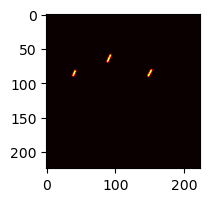

In [7]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
target_size = (224, 224)
gt = heatmap[2].unsqueeze(0)
print(gt.shape)
gt = F.interpolate(
                gt.unsqueeze(0), size=target_size,
                mode='bilinear', align_corners=False
            )  # -> (B, C, Ht, Wt)
pred = gt.squeeze(0)
plt.subplots(figsize=(2, 2))
plt.imshow(pred.squeeze(0), cmap='hot')

#plt.colorbar()
plt.show()

torch.Size([224, 224])
torch.Size([1, 224, 224])


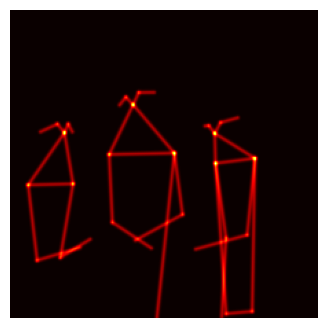

In [12]:
# Assume `heatmaps` has shape (num_keypoints, H, W)
import matplotlib.pyplot as plt

summed_heatmap = heatmap.sum(dim=0)  # Shape: (H, W)
summed_heatmap /= summed_heatmap.max()  # Normalize to range [0, 1]
print(summed_heatmap.shape)

skt = summed_heatmap.unsqueeze(0)
summed_heatmap = F.interpolate(
                skt.unsqueeze(0), size=target_size,
                mode='bilinear', align_corners=False
            )  # -> (B, C, Ht, Wt)
summed_heatmap = summed_heatmap.squeeze(0)
print(summed_heatmap.shape)


# Assuming `image` is the original image (H, W, C)
#plt.imshow(image, alpha=0.5)  # Original image
plt.subplots(figsize=(4, 4))
plt.imshow(summed_heatmap.squeeze(0), cmap='hot')
#plt.colorbar()
plt.axis('off')
plt.show()

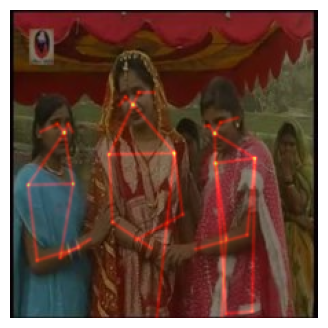

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))


# Display original image
plt.imshow(img, alpha=0.99)

# Overlay the skeleton heatmap
plt.imshow(summed_heatmap.squeeze(0), cmap='hot', alpha=0.5)  # jet or hot colormap shows heat clearly

plt.axis('off')
#plt.title("Predicted Skeleton Overlay")
plt.show()
